In [64]:
import sys
sys.path.append("..")

import datetime as dt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from ros_database.processing.surface import load_station_metadata, load_station_combined_data
from ros_database.filepath import SURFOBS_COMBINED_PATH

from src.utils import ROSCombinedDataFrame, to_daily_climatology, event_frequency_climatology
from src.define_winter import get_por

In [2]:
station = load_station_metadata()
station.head()

,station_name,latitude,longitude,elevation,record_begins,iem_network,state,country,climate_site,wfo,tzname,ncdc81,ncei91,ugc_county,ugc_zone,county,network,start_year,end_year,geometry
stid,,,,,,,,,,,,,,,,,,,,
PALP,Alpine,70.34430,-150.94470,7.998743,2005-03-01 00:00,AK_ASOS,AK,US,AK3275,AFG,America/Anchorage,USC00502126,USC00500235,AKC185,AKZ203,North Slope,AK_ASOS,2005,2022,POINT (-150.9447 70.3443)
PAFM,AMBLER,67.10631,-157.85747,88.000000,1988-01-05 00:00,AK_ASOS,AK,US,AKTAKN,AFG,America/Anchorage,USC00503212,USC00503212,AKC188,AKZ217,Northwest Arctic,AK_ASOS,1988,2022,POINT (-157.85747 67.10631)
PAKP,ANAKTUVUK PASS,68.13360,-151.74334,643.000000,1980-09-11 00:00,AK_ASOS,AK,US,AK3275,AFG,America/Anchorage,USW00026533,USW00026533,AKC185,AKZ206,Yukon-koyukuk,AK_ASOS,1980,2022,POINT (-151.74334 68.1336)
PANC,ANCHORAGE INTL ARPT (ASOS),61.16972,-150.02611,40.000000,1953-11-01 00:00,AK_ASOS,AK,US,AKTANC,AFC,America/Anchorage,USW00026451,USW00026451,AKC020,AKZ101,Kenai Peninsula,AK_ASOS,1953,2022,POINT (-150.02611 61.16972)
PANV,ANVIK AIRPORT,62.64733,-160.19007,99.000000,1994-12-31 00:00,AK_ASOS,AK,US,AKTAKN,AFG,America/Anchorage,USW00026502,USW00026502,AKC290,AKZ215,Yukon-koyukuk,AK_ASOS,1994,2022,POINT (-160.19007 62.64733)


In [31]:
station.loc["BIKF"]

station_name                       Keflavik
latitude                           63.97468
longitude                         -22.58758
elevation                              54.0
record_begins              1942-09-30 00:00
iem_network                        IS__ASOS
state                                   NaN
country                                  IS
climate_site                            NaN
wfo                                     NaN
tzname                   Atlantic/Reykjavik
ncdc81                                  NaN
ncei91                                  NaN
ugc_county                              NaN
ugc_zone                                NaN
county                                  NaN
network                            IS__ASOS
start_year                             1942
end_year                               2022
geometry         POINT (-22.58758 63.97468)
Name: BIKF, dtype: object

In [3]:
station[station.country == "RU"]

,station_name,latitude,longitude,elevation,record_begins,iem_network,state,country,climate_site,wfo,tzname,ncdc81,ncei91,ugc_county,ugc_zone,county,network,start_year,end_year,geometry
stid,,,,,,,,,,,,,,,,,,,,
UHMA,Anadyr,64.78333,177.56667,62.0,1933-12-01 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Anadyr,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1933,2022,POINT (177.56667 64.78333)
ULAA,Arkhangelsk,64.50417,40.72778,19.0,1931-01-03 00:00,RU__ASOS,NaN,RU,NaN,NaN,Europe/Moscow,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1931,2022,POINT (40.72778 64.50417)
UESO,Chokurdah,70.62400,147.89800,26.0,2003-10-29 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Magadan,NaN,NaN,NaN,NaN,NaN,RU__ASOS,2003,2013,POINT (147.898 70.624)
UOII,Igarka,67.46667,86.56667,31.0,2003-12-26 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Krasnoyarsk,NaN,NaN,NaN,NaN,NaN,RU__ASOS,2003,2013,POINT (86.56667 67.46667)
USHH,Khanty-Mansiysk,61.01667,69.03333,23.0,1931-12-31 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Yekaterinburg,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1931,2022,POINT (69.03333 61.01667)
UOHH,Khatanga,71.97722,102.46639,33.0,2001-07-21 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Krasnoyarsk,NaN,NaN,NaN,NaN,NaN,RU__ASOS,2001,2013,POINT (102.46639 71.97722)
USRK,Kogalym,62.19040,74.53380,68.0,1988-11-30 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Yekaterinburg,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1988,2017,POINT (74.5338 62.1904)
ULKK,Kotlas,61.23944,46.68944,56.0,1948-01-04 00:00,RU__ASOS,NaN,RU,NaN,NaN,Europe/Moscow,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1948,2013,POINT (46.68944 61.23944)
UHMM,Magadan,59.91099,150.72044,118.0,1945-12-31 00:00,RU__ASOS,NaN,RU,NaN,NaN,Asia/Magadan,NaN,NaN,NaN,NaN,NaN,RU__ASOS,1945,2022,POINT (150.72044 59.91099)


In [4]:
station[station.station_name.str.contains("YELLOW")]

,station_name,latitude,longitude,elevation,record_begins,iem_network,state,country,climate_site,wfo,tzname,ncdc81,ncei91,ugc_county,ugc_zone,county,network,start_year,end_year,geometry
stid,,,,,,,,,,,,,,,,,,,,
CYZF,YELLOWKNIFE,62.46278,-114.44028,206.0,1942-07-01 00:00,CA_NT_ASOS,NT,CA,NaN,NaN,America/Yellowknife,NaN,NaN,NaN,NaN,NaN,CA_NT_ASOS,1942,2022,POINT (-114.44028 62.46278)


## Load data for a single station

Some useful stations for testing are

| Station | `stid` | SOG |
|---------|--------|-----|
| Anchorage | PANC | No |
| Alpine | PALP | Yes |
| Fairbanks | PAFA |
| Alert | CYLT | No |
| Cambridge Bay | CYCB | No |
| Helsinki | EFHK | Yes |
| Rovaniemi | EFRO | Yes |
| Ny Alesund | ENAL | No |

Data are loaded into a `ROSCombinedDataFrame` object, which is a subclass of a `pandas.DataFrame`

In [57]:
# stid="CYZF"
stid = "BGAA"
df = ROSCombinedDataFrame.from_file(list(SURFOBS_COMBINED_PATH.glob(f"{stid}*.csv"))[0])
df.head()

,station,t2m,d2m,relh,mslp,psurf,p01i,UP,RA,FZRA,SOLID,wspd,drct,sog
datetime,,,,,,,,,,,,,,
2001-07-21 09:00:00,BGAA,9.0,4.0,70.88,NaN,1009.1,NaN,NaN,NaN,NaN,NaN,3.09,69.9,NaN
2001-07-21 10:00:00,BGAA,10.0,1.0,53.54,NaN,1009.1,NaN,NaN,NaN,NaN,NaN,5.14,90.0,NaN
2001-07-21 11:00:00,BGAA,11.0,0.0,46.59,NaN,1009.1,NaN,NaN,NaN,NaN,NaN,4.63,90.0,NaN
2001-07-21 12:00:00,BGAA,11.0,0.0,46.59,NaN,1009.1,NaN,NaN,NaN,NaN,NaN,4.12,90.0,NaN
2001-07-21 13:00:00,BGAA,10.0,3.0,61.76,NaN,1009.1,NaN,NaN,NaN,NaN,NaN,4.63,70.0,NaN


In [58]:
print(f"SOG all missing: {df.sog.isnull().all()}")
print(f"SOG valid: {df.sog.notnull().sum()}")
print(f"SOG count: {df.sog.sum()}")

SOG all missing: True
SOG valid: 0
SOG count: 0.0


We can identify liquid precipitation events using `set_ptype_liquid`.  The default is to set any hour with either `RA` or `FZRA` or both as True. 

In [59]:
df.set_ptype_liquid(inplace=True)

A daily time series can be created with the `to_daily` method.

In [60]:
df_day = df.to_daily()
df_day

,t2m,p01i,sog,LIQUID,RA,FZRA,SOLID,UP
datetime,,,,,,,,
2001-07-21,10.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2014-07-20,12.717391,NaN,NaN,True,True,False,False,False
2014-07-21,9.812500,NaN,NaN,True,True,False,False,False
2014-07-22,10.625000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
get_por(df_day["1979":"2022"].t2m.notnull())

(Timestamp('2001-07-21 00:00:00'),
 Timestamp('2014-07-24 00:00:00'),
 4752,
 np.float64(30.387205387205388))

In [65]:
df_day.index[0] > dt.datetime(1979,1,1)

True

## Calculate daily climatological values

Currently, this does not account for record length.  I might also need to add a windowing function to get a better average.

In [37]:
df_clim = to_daily_climatology(df_day)

In [38]:
fliquid = event_frequency_climatology(df_day.LIQUID)
fsolid = event_frequency_climatology(df_day.SOLID)

In polar latitudes, The climatological first and last days of winter can be defined as the dates when average daily temperature drops below $0 ^\circ\! \mathrm{C}$ permanently.

<Axes: xlabel='datetime'>

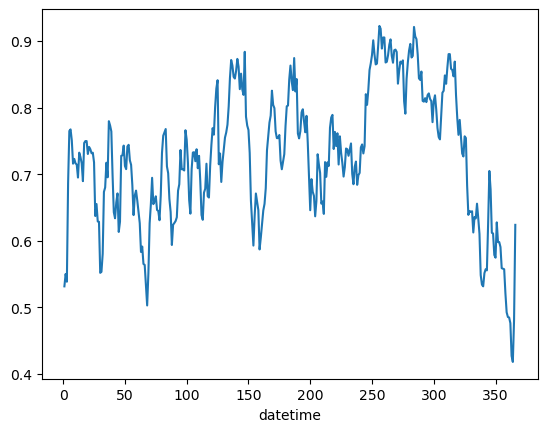

In [39]:
fliquid.plot()

In [40]:
last_day = df_clim.t2m[df_clim.t2m > 0.].index[0]
first_day = df_clim.t2m[df_clim.t2m > 0.].index[-1]
print(f"First day of winter:{first_day}")
print(f"Last day of winter: {last_day}")
print(f"Day of average maximum temperature: {df_clim.t2m.argmax():03d}")

First day of winter:366
Last day of winter: 1
Day of average maximum temperature: 210


For each station get average date of annual maximum temperature

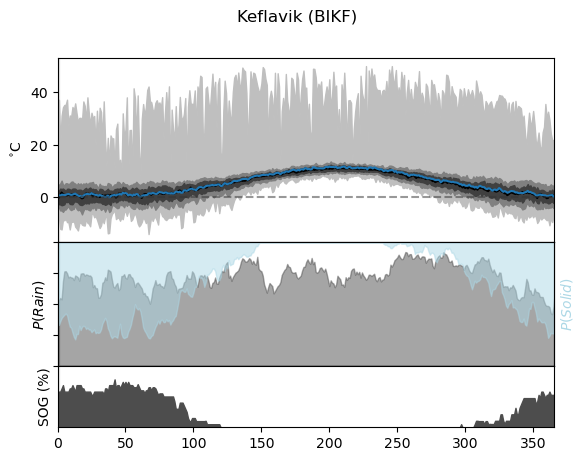

In [41]:
iswinter_color = "0.9"

quantile_colors = ["0.75", "0.5", "0.25"]
median_color = "k"
tavg_color = "tab:blue"

fig = plt.figure()
gs = GridSpec(3, 1, height_ratios=[3, 2, 1], hspace=0)

# Temperature Panel
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0,365)

# - quantiles
for l, u, color in zip(["t2m_min", "t2m_10", "t2m_25"],
                       ["t2m_max", "t2m_90", "t2m_75"], 
                       quantile_colors):
    ax1.fill_between(df_clim.index, df_clim[l], df_clim[u], color=color)
ax1.plot(df_clim.index, df_clim["t2m_50"], color=median_color)
# - average
ax1.plot(df_clim.index, df_clim.t2m, color="tab:blue")
ax1.axhline(0., ls="--", c="0.2", alpha=0.5)
ax1.set_xlabel("Day of Year")
ax1.set_ylabel(r"$^\circ\! \mathrm{C}$");

ax1.tick_params(labelbottom = False, bottom=False)

# Precipitation Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.tick_params(labelbottom = False, bottom=False, labelleft=False, left=False)
ax2.set_ylim(0,1)
ax2.set_ylabel("$P(Rain)$")
ax2.fill_between(fliquid.index, fliquid, color="0.3", alpha=0.5)

ax2b = ax2.twinx()
ax2b.set_ylim(1,0)
ax2b.tick_params(labelright=False, right=False)
ax2b.set_ylabel("$P(Solid)$", color="lightblue")
ax2b.fill_between(fsolid.index, fsolid, color="lightblue", alpha=0.5)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.fill_between(df_clim.sog.index, df_clim.sog, color="0.3")
ax3.set_ylim(0,1)
ax3.set_ylabel("SOG (%)")
ax3.tick_params(labelleft = False, left=False)

for axis in [ax1, ax2, ax3]:
    axis.axvspan(1, last_day, color=iswinter_color, zorder=0)
    axis.axvspan(first_day, 366, color=iswinter_color, zorder=0)
    
fig.suptitle(f"{station.loc[stid].station_name} ({stid})");

fig.savefig(f"../images/{stid}.climatology.png")

To find the start and end of winter for a given year, the definitions needs to be modified to allow for variability in temperatures.

The Swedish Meteorological Institute (SMHI) define the start of thermal winter when daily mean temperatures are below 0 C for five consecutive days.  The start of thermal winter is the first of these five days.

https://web.archive.org/web/20150325164811/http://www.smhi.se/kunskapsbanken/vinter-1.1480

This definition is applied even if daily average temperatures rise above zero again.

In [125]:
def get_freezing_days(s, nday=5):
    """Returns N-day sum of days below freezing"""
    # Set forward window indexer.  Window is today+nday-1
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=nday)
    return (s.interpolate() < 0.).rolling(window=indexer, min_periods=nday).sum()


def get_warming_days(s, nday=5):
    """Returns N-day sum of days at or above freezing"""
        # Set forward window indexer.  Window is today+nday-1
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=nday)
    return (s.interpolate() >= 0.).rolling(window=indexer, min_periods=nday).sum()

    
def get_annual_winter_period(s: pd.Series,
                             nday: int=5):
    """Find start and end of winter period

    We use the SMHI definition of winter, which defines the start of winter
    as the first day of the first N-day period with temperatures below freezing (0 C).
    The default value for N used by SMHI is 5 but can be changed with the `nday` 
    keyword parameter.

    NB: last_day is last day of winter in year, and first_day is first_day of winter
        in same year.  So first_day and last_day do not define start and end of same winter.
        
    Arguments
    ---------
    s : a `pandas.Series` object containing daily average near-surface temperature
    nday : length of the period to evaluate in days

    Returns
    -------
    """

    # t2m_max_date is rough date of maximum temperature
    year = s.index[0].year
    t2m_max_date = f"{year}-08-01"
    
    # Find first day of winter
    # Freezing days are days below 0C
    # freezing_days = (s.interpolate() < 0.).rolling(window=indexer, min_periods=nday).sum()
    freezing_days = get_freezing_days(s)
    try:
        first_day = freezing_days[freezing_days == nday][t2m_max_date:].index[0]
    except IndexError as err:
        print(f"No valid data for range [{t2m_max_date}:], returning NaN")
        first_day = pd.NaT

    # Find last day of winter
    # warming_days are days greater than equal to 0C
    # warming_days = (s.interpolate() >= 0.).rolling(window=indexer, min_periods=nday).sum()
    warming_days = get_warming_days(s)
    try:
        last_day = warming_days[warming_days == nday].index[0]
    except IndexError as err:
        print(f"No valid data for ['{year}'], returning NaN")
        last_day = pd.NaT

    return last_day, first_day
                             

In [126]:
get_annual_winter_period(df_day.loc["2000"].t2m)

(Timestamp('2000-04-19 00:00:00'), Timestamp('2000-10-01 00:00:00'))

In [131]:
# year = 1935
def plot_analysis_metrics(df: pd.DataFrame,
                          fig: plt.Figure=None,
                          ) -> None:
    """Plots temperature and precipitation metrics
    for a single year.

    Arguments
    ---------
    df : DataFrame with t2m, sog (snow on ground), and
         rain, SOLID and UP precipitation types.

    """

    if not fig:
        fig = plt.gcf()

    # Get last and first day of winter
    last_day, first_day = get_annual_winter_period(df.t2m)

    gs = GridSpec(3, 1, height_ratios=[4, 1, 1], hspace=0)

    # Plot 2m temperature time series
    ax1 = fig.add_subplot(gs[0])
    df.t2m.plot(ax=ax1)
    ax1.axhline(0, c="0.5", zorder=1)
    ax1.tick_params(labelbottom = False, bottom=False)
               
    # Plot cumulative freezing and warming days
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    get_freezing_days(df.t2m).plot(ax=ax2, color="tab:blue", label="Freezing Days")
    get_warming_days(df.t2m).plot(ax=ax2, color="tab:red", label="Warm Days")
    ax2.legend()
    ax2.tick_params(labelbottom = False, bottom=False)

    # Plot rain and solid precip events
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.set_ylim(0,3)
    ax3.tick_params(labelleft = False, left=False)
    ax3.eventplot(df[(df.LIQUID == True)].index, lineoffsets=0.5, color="blue")
    ax3.eventplot(df[df.SOLID == True].index, lineoffsets=1.5, color="lightblue")
    ax3.eventplot(df[df.UP == True].index, lineoffsets=2.5, color="orange")

    # Add shaded regions to indicate winter
    if pd.notnull(last_day):
        [axis.axvspan(df.index[0],last_day, color=iswinter_color, zorder=0)
         for axis in [ax1, ax2, ax3]]
        print(f"Last day of winter: {last_day:'%Y-%m-%d'}")
    if pd.notnull(first_day):
        [axis.axvspan(first_day, df.index[-1], color=iswinter_color, zorder=0)
         for axis in [ax1, ax2, ax3]]
        print(f"First day of winter: {first_day:'%Y-%m-%d'}")



Last day of winter: '2020-04-28'
First day of winter: '2020-10-13'


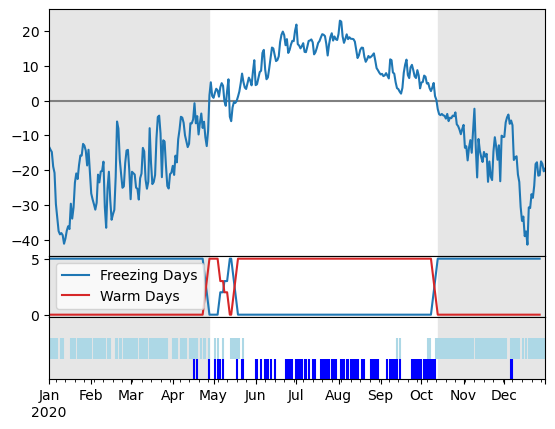

In [132]:
plot_analysis_metrics(df_day.loc["2020"])

In [133]:
columns = ["last_day", "first_day", "duration"]
# winter = [dict(get_annual_winter_period(df_day.loc[f"{year}"].t2m), columns) 
# winter
winter = []
for year in df_day.index.year.unique():
    # print(f"Getting {year}")
    winter.append(dict(zip(columns, 
                           get_annual_winter_period(df_day.loc[f"{year}"].t2m))))


No valid data for ['1948'], returning NaN
No valid data for range [1949-08-01:], returning NaN
No valid data for ['1949'], returning NaN
No valid data for range [1950-08-01:], returning NaN
No valid data for ['1950'], returning NaN
No valid data for range [1951-08-01:], returning NaN
No valid data for ['1951'], returning NaN
No valid data for range [1952-08-01:], returning NaN
No valid data for ['1952'], returning NaN
No valid data for range [1953-08-01:], returning NaN
No valid data for ['1953'], returning NaN
No valid data for range [1954-08-01:], returning NaN
No valid data for ['1954'], returning NaN
No valid data for range [1963-08-01:], returning NaN
No valid data for range [1964-08-01:], returning NaN
No valid data for ['1964'], returning NaN
No valid data for range [1965-08-01:], returning NaN
No valid data for ['1965'], returning NaN
No valid data for range [1966-08-01:], returning NaN
No valid data for ['1966'], returning NaN
No valid data for range [1967-08-01:], returning N

In [134]:
df_winter = pd.DataFrame(winter, index=df_day.index.year.unique())
df_winter = pd.concat([df_winter.last_day, df_winter.first_day.shift(periods=1)], axis=1)
df_winter
# df_winter['last_day'].shift(periods=[0,1])

,last_day,first_day
datetime,,
1942,1942-07-01,NaT
1943,1943-04-18,1942-10-20
1944,1944-04-10,1943-10-28
1945,1945-05-13,1944-10-26
1946,1946-04-26,1945-10-25
...,...,...
2019,2019-04-09,2018-09-29
2020,2020-04-28,2019-10-17
2021,2021-05-04,2020-10-13


<Axes: xlabel='datetime'>

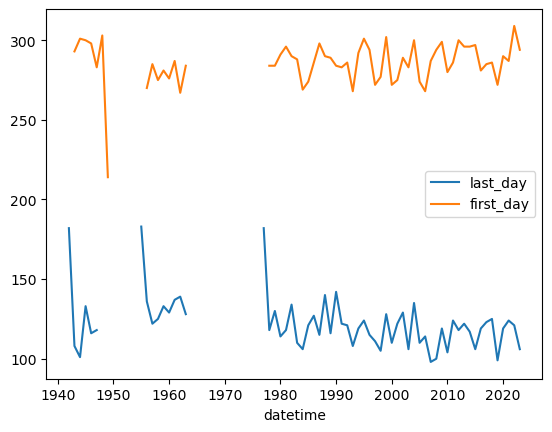

In [135]:
df_winter.apply(lambda x: x.dt.dayofyear).plot()

In [106]:
freezing[freezing == 5].index[0]

np.int64(5)

In [178]:
a = [-4,-3,-2,-1,0,1, 2, 4, -2, -1, 2, 6, 7]
index = pd.date_range("2025-04-21", periods=len(a), freq="D")
s = pd.Series(a, index=index)
s

2025-04-21   -4
2025-04-22   -3
2025-04-23   -2
2025-04-24   -1
2025-04-25    0
2025-04-26    1
2025-04-27    2
2025-04-28    4
2025-04-29   -2
2025-04-30   -1
2025-05-01    2
2025-05-02    6
2025-05-03    7
Freq: D, dtype: int64

In [206]:
x = (s < 0)
x.cumsum().where(s < 0, 0)

2025-04-21    1
2025-04-22    2
2025-04-23    3
2025-04-24    4
2025-04-25    0
2025-04-26    0
2025-04-27    0
2025-04-28    0
2025-04-29    5
2025-04-30    6
2025-05-01    0
2025-05-02    0
2025-05-03    0
Freq: D, dtype: int64

In [203]:
c = x.groupby((x != x.shift()).cumsum()).transform('size')
c.where(x, 0)

2025-04-21    4
2025-04-22    4
2025-04-23    4
2025-04-24    4
2025-04-25    0
2025-04-26    0
2025-04-27    0
2025-04-28    0
2025-04-29    2
2025-04-30    2
2025-05-01    0
2025-05-02    0
2025-05-03    0
Freq: D, dtype: int64

In [196]:
x.cumsum()

2025-04-21    -4.0
2025-04-22    -7.0
2025-04-23    -9.0
2025-04-24   -10.0
2025-04-25     NaN
2025-04-26     NaN
2025-04-27     NaN
2025-04-28     NaN
2025-04-29   -12.0
2025-04-30   -13.0
2025-05-01     NaN
2025-05-02     NaN
2025-05-03     NaN
Freq: D, dtype: float64